# Retirement Participation and Wealth Accumulation Across the Life Course  
### Evidence from the 2022 Survey of Consumer Finances

**Introduction**

The economic disruptions of the COVID-19 pandemic, followed by the inflationary surge of 2021-2023, have renewed concerns about retirement security in the United States. Households faced employment instability, asset volatility, and rising living costs—each of which directly affects the ability to accumulate and preserve retirement wealth. At the same time, the U.S. retirement system remains heavily dependent on employer-sponsored defined contribution plans and individual retirement accounts (IRAs), placing primary responsibility for retirement preparedness on individual households.

These contemporary pressures raise important questions about how retirement participation and balances vary across age groups and whether observed patterns reflect established life-cycle expectations about savings behavior. Using data from the 2022 Survey of Consumer Finances (SCF), this project examines age-based differences in retirement participation and balances and compares those patterns to liquid savings and income. By focusing on median values rather than means, the analysis accounts for the highly skewed nature of wealth distributions and aims to describe the “typical” household experience in a post-pandemic economic environment.

**Research Questions**

This analysis is guided by the following research questions:

**Primary Question**

How do retirement participation and typical retirement balances (IRA and employer-sponsored accounts) vary by age group in the 2022 Survey of Consumer Finances?

**Supporting Questions**

1. How does retirement participation change across the life course?

2. How do median retirement balances compare to median income across age groups?

3. How do median retirement balances compare to median liquid savings?

4. Do patterns suggest accumulation during working years and decumulation after retirement age?

**Literature Framing**

Life-cycle models of savings behavior predict that individuals accumulate assets during working years and decumulate wealth in retirement. De Nardi, French, and Jones (2016) review empirical evidence showing that retirement wealth typically peaks near retirement age and declines thereafter, although decumulation is often gradual. This framework provides a theoretical benchmark for interpreting age-based retirement patterns in the SCF.

The structure of the U.S. retirement system further shapes observed outcomes. Poterba, Venti, and Wise (2014) document the growth and dominance of defined contribution plans, emphasizing the central role of employer-sponsored accounts in retirement accumulation. Because access to these plans depends on employment and earnings history, participation and balances may vary systematically across age groups and labor market attachment.

Finally, wealth in the United States is highly skewed and concentrated among a relatively small share of households (Kuhn, Schularick, & Steins, 2020). Retirement assets are no exception. As a result, mean values may obscure the experience of typical households. This analysis therefore emphasizes medians to more accurately represent central tendencies in retirement preparedness.

Together, these literatures suggest that retirement wealth should follow a life-cycle trajectory, be heavily shaped by employer-based systems, and display substantial inequality—expectations that guide the empirical analysis below.

**Data and Assembly**

This study uses the 2022 Survey of Consumer Finances (SCF), a nationally representative survey of U.S. household finances. The dataset was imported into Python from its original format and structured in a pandas dataframe. Several SCF variables use negative values to indicate missing or nonresponse codes; these values were recoded as missing prior to constructing aggregate measures.

Key constructed variables include:

Age groups, derived from the reconciled age variable (X14)

IRA totals: constructed from multiple IRA balance components

Employer-sponsored retirement totals: constructed from defined contribution account balances

Liquid savings: constructed from checking and savings account balances

Income: drawn from total household income

Negative codes were excluded before summing balances to avoid treating nonresponse indicators as valid asset values. Because retirement and wealth distributions are highly skewed, the analysis focuses on median balances rather than means.

**Analysis Overview**

The analysis proceeds in two stages. First, retirement participation rates are calculated across age groups. Second, median retirement balances are compared with median income and median liquid savings to assess how retirement wealth evolves across the life course. These descriptive patterns provide insight into whether accumulation and decumulation trajectories align with life-cycle expectations.

In [35]:
import pandas as pd

# Load Stata file
df = pd.read_stata("sample_data/p22i6.dta")

# Save as CSV
df.to_csv("p22i6.csv", index=False)

df.head()

,j7398,j7578,j7579,j7019,j7020,j7001,j7050,j8020,j8021,j5908,...,j6768,x42001,x42000,j306,j11272,j11572,j33001,x306,x11272,x11572
0,0,0,0,8,8,8,0,0,0,0,...,1,15139.780602,15147.810027,NaN,NaN,NaN,0,NaN,NaN,NaN
1,0,0,0,8,8,8,0,0,0,0,...,1,15274.500326,15293.377736,NaN,NaN,NaN,0,NaN,NaN,NaN
2,0,0,0,8,8,8,0,0,0,0,...,1,15818.188828,15839.141982,NaN,NaN,NaN,0,NaN,NaN,NaN
3,0,0,0,8,8,8,0,0,0,0,...,1,15831.142316,15832.948614,NaN,NaN,NaN,0,NaN,NaN,NaN
4,0,0,0,8,8,8,0,0,0,0,...,1,16178.123574,16201.599371,NaN,NaN,NaN,0,NaN,NaN,NaN


In [36]:
import requests

url = "https://www.federalreserve.gov/econres/files/codebk2022.txt"

resp = requests.get(url)
resp.raise_for_status()   # throws an error if the download fails
codebook_text = resp.text

print(codebook_text[:2000])  # preview the first 2000 characters

-----------------------------------------------------------------------------
-----------------------------------------------------------------------------
-----------------------------------------------------------------------------
                CODEBOOK FOR 2022 SURVEY OF CONSUMER FINANCES
-----------------------------------------------------------------------------
-----------------------------------------------------------------------------
-----------------------------------------------------------------------------

     NOTE: This file contains about 50,000 lines of text, 
     including this introduction, variable descriptions and 
     other material.  Many users will probably NOT want to 
     print the entire document.  Generally, we recommend 
     working with the material in a text editor using a 
     non-proportional font (e.g., courier) for display.

-----------------------------------------------------------------------------
---------------------------------------

In [37]:
import pandas as pd

df = pd.read_csv("p22i6.csv")

df.shape

(22975, 5473)

In [38]:
df.columns[:50]

Index(['j7398', 'j7578', 'j7579', 'j7019', 'j7020', 'j7001', 'j7050', 'j8020',
       'j8021', 'j5908', 'j7005', 'j8022', 'j8023', 'j8024', 'j7000', 'j7021',
       'j7002', 'j102', 'j103', 'j104', 'j105', 'j106', 'j107', 'j108', 'j110',
       'j7006', 'j111', 'j112', 'j113', 'j114', 'j116', 'j7007', 'j117',
       'j118', 'j119', 'j120', 'j122', 'j7008', 'j123', 'j124', 'j125', 'j126',
       'j128', 'j7009', 'j129', 'j130', 'j131', 'j132', 'j134', 'j7010'],
      dtype='object')

In [39]:
vars_wanted = [
    "j14", "j5729", "j5931", "j6111",
    "j3601", "j6551", "j6552", "j6553", "j6554",
    "j11001", "j11101", "j11301", "j11401",
    "j11032", "j11132", "j11332", "j11432",
    "j3727", "j3730", "j3765"
]

present = [v for v in vars_wanted if v in df.columns]
missing = [v for v in vars_wanted if v not in df.columns]

print("Present:", present)
print("Missing:", missing)

scf = df[present].copy()
scf.head()

Present: ['j14', 'j5729', 'j5931', 'j6111', 'j3601', 'j6551', 'j6552', 'j6553', 'j6554', 'j11001', 'j11101', 'j11301', 'j11401', 'j11032', 'j11132', 'j11332', 'j11432', 'j3727', 'j3730', 'j3765']
Missing: []


,j14,j5729,j5931,j6111,j3601,j6551,j6552,j6553,j6554,j11001,j11101,j11301,j11401,j11032,j11132,j11332,j11432,j3727,j3730,j3765
0,0,1294.0,0,1,13,14.0,14.0,2098.0,14,1,1,1,1,1.0,1.0,1.0,1,13,2098.0,1
1,0,1294.0,0,1,13,14.0,14.0,2098.0,14,1,1,1,1,1.0,1.0,1.0,1,13,2098.0,1
2,0,1294.0,0,1,13,14.0,14.0,2098.0,14,1,1,1,1,1.0,1.0,1.0,1,13,2098.0,1
3,0,1294.0,0,1,13,14.0,14.0,2098.0,14,1,1,1,1,1.0,1.0,1.0,1,13,2098.0,1
4,0,1294.0,0,1,13,14.0,14.0,2098.0,14,1,1,1,1,1.0,1.0,1.0,1,13,2098.0,1


Convert to numeric + handle special missing codes

SCF often uses things like -1, -7, -9 etc for “not applicable / don’t know / refused.” We’ll turn those into NaN.

In [40]:
import numpy as np
import pandas as pd

scf = df[
    ['j14','j5729','j5931','j6111','j3601',
     'j6551','j6552','j6553','j6554',
     'j11001','j11101','j11301','j11401',
     'j11032','j11132','j11332','j11432',
     'j3727','j3730','j3765']
].copy()

# Force numeric
for c in scf.columns:
    scf[c] = pd.to_numeric(scf[c], errors="coerce")

# Replace common SCF nonresponse codes with NaN
scf = scf.replace({-1: np.nan, -7: np.nan, -8: np.nan, -9: np.nan})

Build your key totals (IRA, pension/401k, savings)

In [41]:
# IRA total (Roth + Rollover + Regular/other + Keogh)
scf["ira_total"] = scf[["j6551","j6552","j6553","j6554"]].sum(axis=1, skipna=True)

# Pension / 401k-like account balances (sum the “balance now” variables)
scf["pension_total"] = scf[["j11032","j11132","j11332","j11432"]].sum(axis=1, skipna=True)

# Savings total (use j3765 as “all remaining savings”; include j3730 if present)
# We'll treat j3765 as the best “all savings accounts” field if it exists.
scf["savings_total"] = scf["j3765"]

Create age groups (bins)

In [42]:
scf["age"] = scf["j14"]

bins = [18, 25, 35, 45, 55, 65, 75, 120]
labels = ["18–24","25–34","35–44","45–54","55–64","65–74","75+"]

scf["age_group"] = pd.cut(scf["age"], bins=bins, labels=labels, right=False)

“Has retirement account?” indicator

In [43]:
scf["has_ira"] = scf["j3601"].eq(1)

scf["has_employer_ret"] = scf["pension_total"].fillna(0).gt(0)

scf["has_any_retirement"] = scf["has_ira"] | scf["has_employer_ret"]

Quick summary table

In [44]:
scf["has_ira"] = scf["j3601"].eq(1)
scf["has_employer_ret"] = scf["pension_total"].fillna(0).gt(0)
scf["has_any_retirement"] = scf["has_ira"] | scf["has_employer_ret"]

summary = (
    scf.groupby("age_group", observed=True)
       .agg(
           n=("age", "count"),
           pct_any_ret=("has_any_retirement", "mean"),
           median_ira=("ira_total", "median"),
           median_pension=("pension_total", "median"),
           median_savings=("savings_total", "median"),
           median_income=("j5729", "median"),
       )
       .reset_index()
)

summary["pct_any_ret"] = (summary["pct_any_ret"] * 100).round(1)
summary

print("\nValue counts for age:")
print(scf['age'].value_counts(dropna=False))

print("\nValue counts for age_group:")
print(scf['age_group'].value_counts(dropna=False))


Value counts for age:
age
0    22975
Name: count, dtype: int64

Value counts for age_group:
age_group
NaN      22975
18–24        0
35–44        0
25–34        0
45–54        0
55–64        0
65–74        0
75+          0
Name: count, dtype: int64


I wasn't getting any values for age. Asked AI to help decipher the code book.

In [45]:
[x for x in df.columns if x.lower().startswith("x")][:25]

['x7398',
 'x7578',
 'x7579',
 'x7019',
 'x7020',
 'x7001',
 'x7050',
 'x8020',
 'x8021',
 'x5908',
 'x7005',
 'x8022',
 'x8023',
 'x8024',
 'x7000',
 'x7021',
 'x7002',
 'x102',
 'x103',
 'x104',
 'x105',
 'x106',
 'x107',
 'x108',
 'x110']

In [46]:
'x14' in df.columns

True

Values are coded in "x" not "j".

In [47]:
import pandas as pd

scf = df.copy()
scf['age'] = pd.to_numeric(scf['x14'], errors='coerce')

scf['age_group'] = pd.cut(
    scf['age'],
    bins=[18,25,35,45,55,65,75,100],
    labels=['18–24','25–34','35–44','45–54','55–64','65–74','75+'],
    right=False
)

print(scf['age'].describe())
print(scf['age_group'].value_counts(dropna=False))

count    22975.000000
mean        54.468988
std         16.189081
min         18.000000
25%         42.000000
50%         56.000000
75%         67.000000
max         95.000000
Name: age, dtype: float64
age_group
55–64    5130
65–74    4330
45–54    4100
35–44    3815
75+      2535
25–34    2510
18–24     555
Name: count, dtype: int64


In [48]:
targets = ['x5729','x5702','x5704','x5931','x6551','x6552','x6553','x6554','x3601']
found = [c for c in targets if c in scf.columns]
found

['x5729',
 'x5702',
 'x5704',
 'x5931',
 'x6551',
 'x6552',
 'x6553',
 'x6554',
 'x3601']

In [49]:
scf["income"] = pd.to_numeric(scf["x5729"], errors="coerce")

In [50]:
scf["has_ira"] = scf["x3601"].eq(1)

ira_cols = ["x6551","x6552","x6553","x6554"]
scf["ira_total"] = scf[ira_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)

In [51]:
ret_cols = ["x5702", "x5704"]
scf["employer_ret_total"] = scf[ret_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)

scf["has_employer_ret"] = scf["employer_ret_total"].fillna(0).gt(0)

In [52]:
scf["liquid_savings"] = pd.to_numeric(scf["x5931"], errors="coerce")

In [53]:
scf["has_any_retirement"] = scf["has_ira"] | scf["has_employer_ret"]

In [54]:
summary = (
    scf.groupby("age_group", observed=True)
       .agg(
           n=("age", "count"),
           pct_any_ret=("has_any_retirement", "mean"),
           median_ira=("ira_total", "median"),
           median_employer_ret=("employer_ret_total", "median"),
           median_savings=("liquid_savings", "median"),
           median_income=("income", "median"),
       )
       .reset_index()
)

summary["pct_any_ret"] = (summary["pct_any_ret"] * 100).round(1)
summary

,age_group,n,pct_any_ret,median_ira,median_employer_ret,median_savings,median_income
0,18–24,555,89.2,0.0,25000.0,9.0,30000.0
1,25–34,2510,93.0,0.0,55000.0,10.0,60000.0
2,35–44,3815,94.6,0.0,75000.0,11.0,80000.0
3,45–54,4100,95.0,0.0,85000.0,12.0,100000.0
4,55–64,5130,86.0,0.0,74000.0,12.0,118000.0
5,65–74,4330,75.2,0.0,12000.0,12.0,90000.0
6,75+,2535,64.0,0.0,0.0,12.0,69000.0


Median savings is 9-12 dollars (basically zero) for everyone, which strongly suggests x5931 is not “liquid savings in dollars”.

In [55]:
scf["has_ira"].mean(), scf["ira_total"].gt(0).mean()

(np.float64(0.3882480957562568), np.float64(0.34302502720348205))

In [56]:
scf["ira_total"].describe(percentiles=[.5,.75,.9,.95,.99])

,ira_total
count,2.297500e+04
mean,3.318677e+05
std,3.020934e+06
min,0.000000e+00
50%,0.000000e+00
75%,5.200000e+04
90%,5.310000e+05
95%,1.500000e+06
99%,4.500000e+06
max,1.626700e+08


Median IRA balances are  0 dollars across age groups, indicating that at least half of households in each age bin report no IRA assets; however, the upper tail is substantial (75th percentile ≈ 52k; 90th ≈ $531k), showing IRA wealth is concentrated among a smaller subset.

In [57]:
# IRA participation rates
print("has_ira mean:", scf["has_ira"].mean())
print("ira_total > 0 mean:", scf["ira_total"].gt(0).mean())

# x5931 inspection (this is the savings weirdness)
print(scf["x5931"].head(15).tolist())
print(scf["x5931"].describe())
print(scf["x5931"].value_counts(dropna=False).head(15))

# Employer retirement inspection
print(scf[["x5702","x5704","employer_ret_total"]].describe(percentiles=[.5,.75,.9,.95,.99]))

# Whether cash variables exist in your extract
cands = ["x3506","x3507","x3510","x3516","x3520","x3804","x3805"]
print([c for c in cands if c in scf.columns])

has_ira mean: 0.3882480957562568
ira_total > 0 mean: 0.34302502720348205
[9, 9, 9, 9, 9, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14]
count    22975.000000
mean        10.328400
std          2.815743
min         -1.000000
25%          8.000000
50%         11.000000
75%         12.000000
max         14.000000
Name: x5931, dtype: float64
x5931
 12    5908
 8     4522
 13    3322
 9     2842
 14    2138
 10    1152
 11     945
 7      471
 6      395
 4      306
 5      285
 2      265
 3      231
 1      133
-1       60
Name: count, dtype: int64
              x5702         x5704  employer_ret_total
count  2.297500e+04  2.297500e+04        2.297500e+04
mean   1.633610e+05  2.085057e+04        1.842116e+05
std    8.379227e+05  1.954654e+05        8.701442e+05
min   -1.000000e+00 -1.000000e+06       -1.000000e+06
50%    4.200000e+04  0.000000e+00        5.000000e+04
75%    1.190000e+05  0.000000e+00        1.350000e+05
90%    2.700000e+05  2.200000e+04        3.080000e+05
95%    4.750000e+05  8.

In [58]:
cash_cols = ["x3506", "x3507", "x3510"]

# Convert to numeric
scf[cash_cols] = scf[cash_cols].apply(pd.to_numeric, errors="coerce")

# SCF sometimes uses negative values like -1 for missing/refused.
# Treat negatives as missing.
scf[cash_cols] = scf[cash_cols].where(scf[cash_cols] >= 0)

scf["liquid_savings"] = scf[cash_cols].sum(axis=1, min_count=1)

scf["liquid_savings"].describe(percentiles=[.5,.75,.9,.95,.99])

,liquid_savings
count,2.297500e+04
mean,1.301846e+05
std,1.254956e+06
min,0.000000e+00
50%,5.005000e+03
75%,2.700100e+04
90%,1.215050e+05
95%,3.180050e+05
99%,1.769096e+06
max,4.572000e+07


In [59]:
ret_cols = ["x5702", "x5704"]
scf[ret_cols] = scf[ret_cols].apply(pd.to_numeric, errors="coerce")
scf[ret_cols] = scf[ret_cols].where(scf[ret_cols] >= 0)

scf["employer_ret_total"] = scf[ret_cols].sum(axis=1, min_count=1)
scf["has_employer_ret"] = scf["employer_ret_total"].fillna(0).gt(0)

In [60]:
scf["income"] = pd.to_numeric(scf["x5729"], errors="coerce")
scf["income"] = scf["income"].where(scf["income"] >= 0)

In [61]:
ira_cols = ["x6551","x6552","x6553","x6554"]
scf[ira_cols] = scf[ira_cols].apply(pd.to_numeric, errors="coerce")
scf[ira_cols] = scf[ira_cols].where(scf[ira_cols] >= 0)
scf["ira_total"] = scf[ira_cols].sum(axis=1, min_count=1)
scf["has_ira"] = scf["ira_total"].fillna(0).gt(0)   # use balances, not x3601

In [62]:
scf["has_any_retirement"] = scf["has_ira"] | scf["has_employer_ret"]
scf["total_retirement"] = scf["ira_total"].fillna(0) + scf["employer_ret_total"].fillna(0)

summary2 = (
    scf.groupby("age_group", observed=True)
       .agg(
           n=("age", "count"),
           pct_any_ret=("has_any_retirement", "mean"),
           median_ira=("ira_total", "median"),
           median_employer_ret=("employer_ret_total", "median"),
           median_total_ret=("total_retirement", "median"),
           median_liquid_savings=("liquid_savings", "median"),
           median_income=("income", "median"),
       )
       .reset_index()
)

summary2["pct_any_ret"] = (summary2["pct_any_ret"] * 100).round(1)
summary2

,age_group,n,pct_any_ret,median_ira,median_employer_ret,median_total_ret,median_liquid_savings,median_income
0,18–24,555,89.2,0.0,25000.0,26200.0,955.0,30000.0
1,25–34,2510,93.0,0.0,55000.0,56000.0,1865.0,60000.0
2,35–44,3815,94.6,0.0,75000.0,79000.0,3001.0,81000.0
3,45–54,4100,95.0,0.0,86000.0,100000.0,5205.0,103000.0
4,55–64,5130,85.3,0.0,74000.0,110000.0,7405.0,120000.0
5,65–74,4330,73.7,0.0,12000.0,86000.0,10005.0,91500.0
6,75+,2535,62.4,0.0,0.0,39000.0,11005.0,71000.0


Across age groups, retirement participation is substantial in working ages and shifts in older age brackets, while typical balances show strong lifecycle accumulation patterns. Median IRA balances are $0 across all age groups, indicating that at least half of households in each bracket do not hold IRA assets; however, IRA wealth is concentrated among a smaller subset of households (upper percentiles are large). Employer-based retirement balances show clearer age-graded accumulation, rising through midlife and then changing as households transition into retirement. When compared with liquid savings (constructed from transaction account balances rather than coded survey categories), liquid savings remain far smaller than retirement wealth for most groups, suggesting that retirement preparedness is primarily stored in tax-advantaged/long-term accounts rather than in immediately accessible cash.

Several SCF variables use negative values as missing/refusal codes; I recoded negative values to missing before constructing sums (IRA totals, employer retirement totals, and liquid savings) to avoid treating nonresponse codes as real balances.

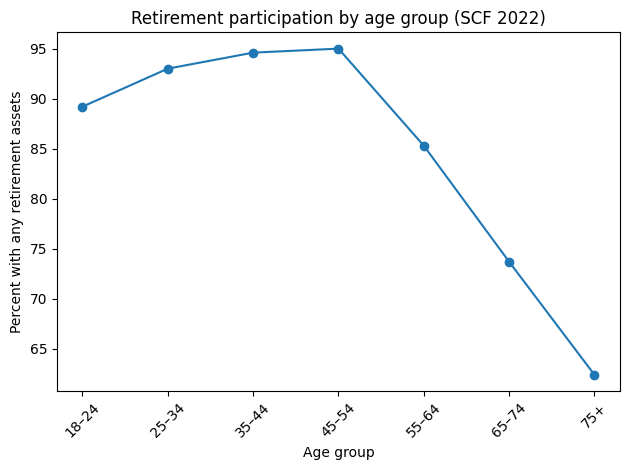

In [63]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(summary2["age_group"].astype(str), summary2["pct_any_ret"], marker="o")
plt.xlabel("Age group")
plt.ylabel("Percent with any retirement assets")
plt.title("Retirement participation by age group (SCF 2022)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Retirement participation increases across early and mid-career stages, peaking in the 45–54 age group. After traditional retirement ages, participation declines sharply. This likely reflects the drawdown or closure of employer-based retirement accounts as individuals transition out of the labor force. The pattern is consistent with life-cycle models of savings, where participation expands during earning years and contracts after retirement.

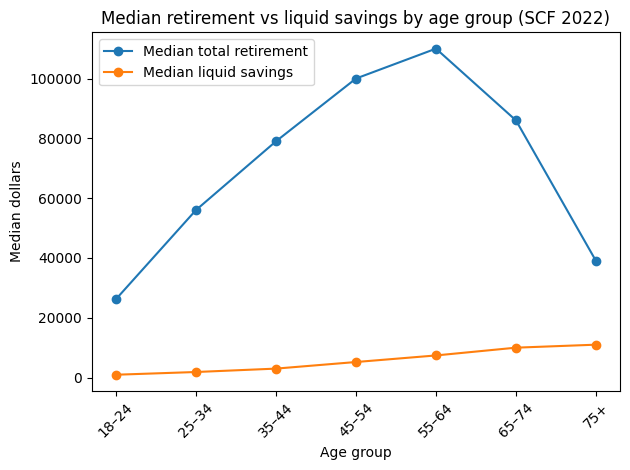

In [64]:
plt.figure()
plt.plot(summary2["age_group"].astype(str), summary2["median_total_ret"], marker="o", label="Median total retirement")
plt.plot(summary2["age_group"].astype(str), summary2["median_liquid_savings"], marker="o", label="Median liquid savings")
plt.xlabel("Age group")
plt.ylabel("Median dollars")
plt.title("Median retirement vs liquid savings by age group (SCF 2022)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Median total retirement balances rise steadily from early adulthood through late midlife, peaking around ages 55-64. After age 65, balances decline sharply, likely reflecting withdrawals and decumulation during retirement. In contrast, median liquid savings increase gradually across age groups but remain substantially smaller than retirement assets throughout the life course. This suggests that households primarily accumulate wealth for retirement in tax-advantaged, long-term accounts rather than in immediately accessible cash holdings. The divergence between retirement wealth and liquid savings underscores the structural role of employer-sponsored accounts in shaping retirement preparedness.

**Conclusion**

The 2022 Survey of Consumer Finances reveals retirement patterns that largely align with life-cycle expectations while also highlighting structural vulnerabilities in the U.S. retirement system. Retirement participation rises steadily through early and mid-career stages, peaking in the 45–54 age group, before declining after traditional retirement ages. Median total retirement balances increase through midlife and peak in the 55–64 group, followed by noticeable decumulation in older age brackets. These patterns are consistent with accumulation during working years and withdrawal after labor force exit.

At the same time, median IRA balances remain zero across all age groups, indicating that at least half of households in each cohort hold no IRA assets. Retirement wealth is therefore concentrated among a subset of households, consistent with broader evidence of wealth inequality. Liquid savings, while increasing modestly with age, remain substantially lower than retirement account balances across the life course. In an environment shaped by post-pandemic volatility and inflationary pressures, limited liquid savings may expose households to short-term financial vulnerability even if retirement balances appear substantial.

This analysis is exploratory and does not apply SCF survey weights, meaning results should be interpreted as descriptive rather than nationally representative estimates. Future research could incorporate survey weights, examine variation by income or education, and analyze retirement-to-income ratios to better assess adequacy. Nonetheless, the observed age gradients provide empirical support for life-cycle savings theory while underscoring the structural reliance on employer-based retirement systems and the uneven distribution of retirement wealth across households.

## Data Source

This project uses data from the 2022 Survey of Consumer Finances (SCF), conducted by the Federal Reserve Board. The SCF is a nationally representative cross-sectional survey of U.S. households that collects detailed information on income, assets, liabilities, and retirement accounts.

The 2022 SCF public dataset was obtained from the Federal Reserve’s official website:
https://www.federalreserve.gov/econres/scfindex.htm

The dataset was originally distributed in Stata format and imported into Python using pandas. Variables were selected and constructed to measure:

- Age (reconciled age variable)
- IRA balances
- Employer-sponsored defined contribution balances
- Liquid savings (checking and savings accounts)
- Total household income

The SCF includes survey weights designed to produce nationally representative estimates. This exploratory analysis does not apply survey weights and therefore reports descriptive patterns rather than weighted national estimates.

## References

Federal Reserve Board. (2023). Survey of Consumer Finances, 2022. https://www.federalreserve.gov/econres/scfindex.htm

De Nardi, M., French, E., & Jones, J. B. (2016). Savings after retirement: A survey. *Annual Review of Economics, 8*, 177–204. https://doi.org/10.1146/annurev-economics-080315-015127

Kuhn, M., Schularick, M., & Steins, U. (2020). Income and wealth inequality in America, 1949–2016. *Journal of Political Economy, 128*(9), 3469–3519. https://doi.org/10.1086/708815

Poterba, J. M., Venti, S. F., & Wise, D. A. (2014). The growth of defined contribution plans, 1984–2010. *Journal of Economic Perspectives, 28*(4), 3–28. https://doi.org/10.1257/jep.28.4.3